<a href="https://colab.research.google.com/github/mdNotFound/100-days-of-ai-engineering/blob/main/DAY9_Image_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torchvision.datasets import OxfordIIITPet
from torch.utils.data import DataLoader

In [2]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("running on", device)

running on cuda


In [3]:
IMAGE_SIZE=128
image_transform=transforms.Compose([
    transforms.Resize((IMAGE_SIZE,IMAGE_SIZE)),
    transforms.ToTensor()
])

In [4]:
def mask_transform(mask):
  mask=mask.resize((IMAGE_SIZE,IMAGE_SIZE),Image.NEAREST)
  mask=np.array(mask,dtype=np.int64)
  binary=(mask==1).astype(np.float32) # pwt => 1.0, else=> 0.0
  return torch.from_numpy(binary).unsqueeze(0) ##(H,W) => (1,H,W)

In [5]:
train_dataset=OxfordIIITPet(
    root="./data",split="trainval",target_types="segmentation",download=True,transform=image_transform,
    target_transform=mask_transform
)
val_dataset=OxfordIIITPet(
    root="./data",split="test",target_types="segmentation",download=True,transform=image_transform,
    target_transform=mask_transform
)

100%|██████████| 792M/792M [00:38<00:00, 20.7MB/s]
100%|██████████| 19.2M/19.2M [00:02<00:00, 9.42MB/s]


In [6]:
print(len(train_dataset))
print(len(val_dataset))

3680
3669


In [7]:
train_loader=DataLoader(train_dataset,batch_size=16,shuffle=True)
val_loader=DataLoader(val_dataset,batch_size=16,shuffle=False)

In [8]:
image_batch,mask_image=next(iter(train_loader))
print("images:",image_batch.shape,image_batch.dtype)
print("mask:",mask_image.shape,mask_image.dtype)
print("mask_values:",torch.unique(mask_image))

images: torch.Size([16, 3, 128, 128]) torch.float32
mask: torch.Size([16, 1, 128, 128]) torch.float32
mask_values: tensor([0., 1.])


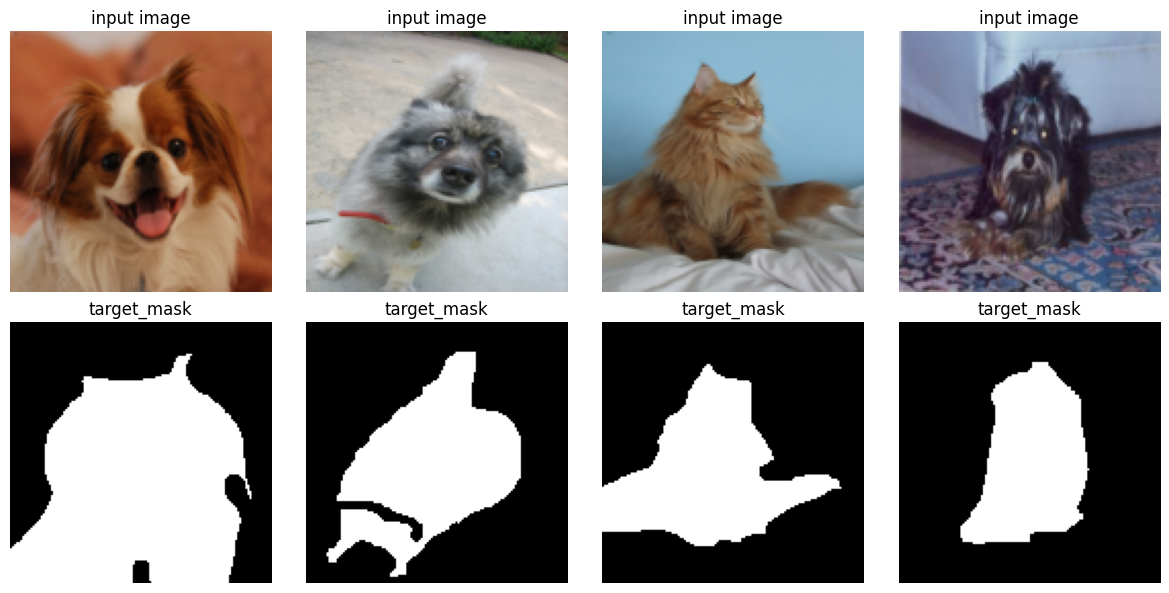

In [9]:
image_batch,mask_batch=next(iter(train_loader))

n=4
figure,axes=plt.subplots(2,n,figsize=(3*n,6))
for i in range(n):
  img=np.transpose(image_batch[i].numpy(),(1,2,0))
  axes[0,i].imshow(img);   axes[0,i].axis("off")
  axes[0,i].set_title("input image")
  axes[1,i].imshow(mask_batch[i,0].numpy(),cmap="gray")
  axes[1,i].axis("off")
  axes[1,i].set_title("target_mask")
plt.tight_layout()
plt.show()

In [20]:
class DoubleConv(nn.Module):
  def __init__(self,in_channels,out_channels):
    super().__init__()
    self.block=nn.Sequential(
        nn.Conv2d(in_channels,out_channels,kernel_size=3,padding=1),
        nn.BatchNorm2d(out_channels),
        nn.ReLU6(inplace=True),
        nn.Conv2d(out_channels,out_channels,kernel_size=3,padding=1),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True),
    )
  def forward(self,x):
    return self.block(x)

In [21]:
class MiniUNet(nn.Module):
  def __init__(self,in_channels=3,out_channels=1): ##input:(B,3,128,128)
    super().__init__()
    self.enc1=DoubleConv(in_channels,32) ##[B,32,128,128]
    self.pool=nn.MaxPool2d(2)
    self.enc2=DoubleConv(32,64)
    self.enc3=DoubleConv(64,128)

    self.bottleneck=DoubleConv(128,256)

    ##decoder
    self.up3=nn.ConvTranspose2d(256,128,kernel_size=2,stride=2)
    self.dec3=DoubleConv(256,128)
    self.up2=nn.ConvTranspose2d(128,64,kernel_size=2,stride=2)
    self.dec2=DoubleConv(128,64)
    self.up1=nn.ConvTranspose2d(64,32,kernel_size=2,stride=2)
    self.dec1=DoubleConv(64,32)

    self.head=nn.Conv2d(32,out_channels,kernel_size=1)

  def forward(self,x):
    e1=self.enc1(x) ##[B,32,128,128]
    e2=self.enc2(self.pool(e1)) ##pool(e1) =>[B,32,64,64] => [B,64,64,64]
    e3=self.enc3(self.pool(e2)) ##pool(e2) =>[B,64,32,32] => [B,128,32,32]

    b=self.bottleneck(self.pool(e3)) ##pool(e2) =>[B,128,16,16] => [B,256,16,16]

    ##decoder
    d3=self.up3(b) ##[B,128,32,32]
    d3=self.dec3(torch.cat([d3,e3],dim=1)) ##[B,256,32,32] => [B,128,32,32]
    d2=self.up2(d3)##[B,64,32,32]
    d2=self.dec2(torch.cat([d2,e2],dim=1)) ##[B,128,64,64] => [B,64,64,64]
    d1=self.up1(d2) ##[B,32,128,128]
    d1=self.dec1(torch.cat([d1,e1],dim=1)) ##[B,64,128,128] => [B,32,128,128]
    return self.head(d1)


In [23]:
model=MiniUNet().to(device)
dummy=torch.randn(2,3,IMAGE_SIZE,IMAGE_SIZE,device=device)
with torch.no_grad():
  out=model(dummy)

n_params=sum(p.numel() for p in model.parameters())
print("input:", tuple(dummy.shape))
print("output:", tuple(out.shape))
print("trainable parameter:",f"{n_params:,}")

input: (2, 3, 128, 128)
output: (2, 1, 128, 128)
trainable parameter: 1,928,417


In [29]:
bce_loss_fn=nn.BCEWithLogitsLoss()
def dice_loss_fn(logits,targets,smooth=1.0):
  probs=torch.sigmoid(logits)
  dims=(1,2,3)
  intersection=(probs * targets).sum(dim=dims)
  union=probs.sum(dim=dims)+ targets.sum(dim=dims)
  dice=(2* intersection+smooth)/(union+smooth)
  return (1-dice).mean()
def combined_loss_fn(logits,targets):
  return bce_loss_fn(logits,targets)+dice_loss_fn(logits,targets)

imgs,msks=next(iter(train_loader))
imgs,msks=imgs.to(device),msks.to(device)
with torch.no_grad():
  lg=model(imgs)
  print("BCE :",round(bce_loss_fn(lg,msks).item(),4))
  print("Dice loss:", round(dice_loss_fn(lg,msks).item(),4))
  print("Combined:", round(combined_loss_fn(lg,msks).item(),4))

BCE : 0.6845
Dice loss: 0.6835
Combined: 1.368


In [31]:
@torch.no_grad()
def dice_coefficient(pred_bool,true_bool,eps=1e-6):
  inter=(pred_bool & true_bool).sum().float()
  total=pred_bool.sum().float() +true_bool.sum().float()
  return ((2*inter+eps)/(total+eps)).item()

@torch.no_grad()
def evaluate(model,loader):
  model.eval()
  dices=[]
  for images,masks in loader:
    images,masks=images.to(device),masks.to(device)
    probs=torch.sigmoid(model(images))
    preds=probs>0.5
    truth=masks>0.5
    for i in range(images.size(0)):
      dices.append(dice_coefficient(preds[i],truth[i]))
  return sum(dices)/len(dices)


In [37]:
model=MiniUNet().to(device)
optimizer=torch.optim.Adam(model.parameters(),lr=1e-3)

EPOCHS=20
step_loss_history=[]
val_dice_history=[]
for epoch in range(EPOCHS):
  model.train()
  running=0.0
  for images,masks in train_loader:
    images,masks=images.to(device),masks.to(device)
    logits=model(images)
    loss=combined_loss_fn(logits,masks)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    step_loss_history.append(loss.item())
    running+= loss.item()

  train_loss=running/len(train_loader)
  val_dice=evaluate(model,val_loader)
  val_dice_history.append(val_dice)
  print(f"epoch {epoch+1}/{EPOCHS} "
        f"train_loss {train_loss:.4f} "
        f"val_dice {val_dice:.4f}")

epoch 1/20 train_loss 0.8907 val_dice 0.7271
epoch 2/20 train_loss 0.6559 val_dice 0.7502
epoch 3/20 train_loss 0.5596 val_dice 0.7992
epoch 4/20 train_loss 0.4973 val_dice 0.8027
epoch 5/20 train_loss 0.4695 val_dice 0.8167
epoch 6/20 train_loss 0.4419 val_dice 0.8067
epoch 7/20 train_loss 0.4198 val_dice 0.8102
epoch 8/20 train_loss 0.3936 val_dice 0.8177
epoch 9/20 train_loss 0.3798 val_dice 0.8409
epoch 10/20 train_loss 0.3645 val_dice 0.8514
epoch 11/20 train_loss 0.3434 val_dice 0.8454
epoch 12/20 train_loss 0.3324 val_dice 0.8518
epoch 13/20 train_loss 0.3222 val_dice 0.8507
epoch 14/20 train_loss 0.2951 val_dice 0.8630
epoch 15/20 train_loss 0.2988 val_dice 0.8533
epoch 16/20 train_loss 0.2842 val_dice 0.8518
epoch 17/20 train_loss 0.2678 val_dice 0.8555
epoch 18/20 train_loss 0.2573 val_dice 0.8595
epoch 19/20 train_loss 0.2479 val_dice 0.8680
epoch 20/20 train_loss 0.2372 val_dice 0.8582
